# Equity Analysis

This notebook compares territorial and population-based equity for Amsterdam, Athens, and Milan. Given a set of POI categories, it computes the Gini Territorial Index and the Gini Population Index (i.e. the Gini index weighted by population) for each category.


In [1]:
import accessx as acx
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
from pathlib import Path


## Setup


In [2]:
epsg_ams = 28992
epsg_ath = 2100
epsg_mil = 32632

resolution = 9
worldpop_year = 2020
buffer = 1000
max_cost = 15
cost_attr = "avg_time"


data_path = Path("../data/case_studies")
equity_path = data_path / "equity"
area_path = equity_path / "area"
population_path = equity_path / "population"
pois_path = equity_path / "pois"
accessibility_path = equity_path / "accessibility"
street_network_path = equity_path / "street_network"
results_path = equity_path / "results"


equity_path.mkdir(parents=True, exist_ok=True)
area_path.mkdir(parents=True, exist_ok=True)
population_path.mkdir(parents=True, exist_ok=True)
pois_path.mkdir(parents=True, exist_ok=True)
accessibility_path.mkdir(parents=True, exist_ok=True)
street_network_path.mkdir(parents=True, exist_ok=True)
results_path.mkdir(parents=True, exist_ok=True)

# Add the POI categories you want to analyse below, using the format:
# "category": {"osm_key": ["osm_value"]}.
# The notebook will automatically calculate the Gini indices for each category.

poi_categories={
    "amenity_bar": {"amenity": ["bar"]},
    "amenity_cafe": {"amenity": ["cafe"]},
    "amenity_cinema": {"amenity": ["cinema"]}, 
    "amenity_pharmacy": {"amenity": ["pharmacy"]},
    "amenity_restaurant": {"amenity": ["restaurant"]},
    "amenity_theatre": {"amenity": ["theatre"]},
    "leisure_playground": {"leisure": ["playground"]},
}


poi_types = [f"count_{category}" for category in poi_categories]




Below is a list of POI categories for reference.

In [ ]:
# poi_library = {
#     # ===================== FOOD / RETAIL =====================
#     "shop_supermarket": {"shop": ["supermarket"]},
#     "shop_grocery": {"shop": ["grocery"]},
#     "shop_convenience": {"shop": ["convenience"]},
#     "shop_bakery": {"shop": ["bakery"]},
#     "shop_butcher": {"shop": ["butcher"]},
#     "shop_greengrocer": {"shop": ["greengrocer"]},
#     # ===================== HEALTHCARE =====================
#     "amenity_pharmacy": {"amenity": ["pharmacy"]},
#     "amenity_doctor": {"amenity": ["doctor"]},
#     "amenity_clinic": {"amenity": ["clinic"]},
#     "amenity_dentist": {"amenity": ["dentist"]},
#     "amenity_hospital": {"amenity": ["hospital"]},

#     # ===================== FOOD / SOCIAL =====================
#     "amenity_cafe": {"amenity": ["cafe"]},
#     "amenity_restaurant": {"amenity": ["restaurant"]},
#     "amenity_fast_food": {"amenity": ["fast_food"]},
#     "amenity_food_court": {"amenity": ["food_court"]},
#     # "amenity_ice_cream": {"amenity": ["ice_cream"]},
#     "amenity_bar": {"amenity": ["bar"]},
#     "amenity_pub": {"amenity": ["pub"]},

#     # ===================== CULTURE =====================
#     "amenity_cinema": {"amenity": ["cinema"]},
#     "amenity_theatre": {"amenity": ["theatre"]},
#     "amenity_arts_centre": {"amenity": ["arts_centre"]},
#     "tourism_museum": {"tourism": ["museum"]},
#     "tourism_gallery": {"tourism": ["gallery"]},
#     "tourism_artwork": {"tourism": ["artwork"]},
#     "tourism_attraction": {"tourism": ["attraction"]},
#     # ===================== GREEN / LEISURE =====================
#     "leisure_park": {"leisure": ["park"]},
#     "leisure_garden": {"leisure": ["garden"]},
#     "leisure_playground": {"leisure": ["playground"]},

#     # ===================== PUBLIC SPACE =====================
#     "place_square": {"place": ["square"]},

#     # ===================== MOBILITY (IMPORTANT – FULLY PRESERVED) =====================
#     "highway_bus_stop": {"highway": ["bus_stop"]},
#     "railway_tram_stop": {"railway": ["tram_stop"]},
#     "railway_subway_entrance": {"railway": ["subway_entrance"]},

# }


## Load Area of Interest


In [ ]:
gdf_ams = ox.geocode_to_gdf("Amsterdam, Netherlands")
acx.save_gdf(gdf_ams, area_path / "aoi_amsterdam.geojson")
#gdf_ams = acx.read_gdf(area_path / "aoi_amsterdam.geojson")

gdf_ath = ox.geocode_to_gdf("Municipality of Athens, Greece")
acx.save_gdf(gdf_ath, area_path / "aoi_athens.geojson")
#gdf_ath = acx.read_gdf(area_path / "aoi_athens.geojson")

gdf_mil = ox.geocode_to_gdf("Milan, Italy")
acx.save_gdf(gdf_mil, area_path / "aoi_milan.geojson")
#gdf_mil = acx.read_gdf(area_path / "aoi_milan.geojson")


## Make Hex Grid


In [4]:
hex_ams = acx.make_hex_grid(gdf_ams, resolution=resolution)
acx.save_gdf(hex_ams, area_path / "hexes_amsterdam.geojson")
# hex_ams = acx.read_gdf(area_path / "hexes_amsterdam.geojson")

hex_ath = acx.make_hex_grid(gdf_ath, resolution=resolution)
acx.save_gdf(hex_ath, area_path / "hexes_athens.geojson")
# hex_ath = acx.read_gdf(area_path / "hexes_athens.geojson")

hex_mil = acx.make_hex_grid(gdf_mil, resolution=resolution)
acx.save_gdf(hex_mil, area_path / "hexes_milan.geojson")
# hex_mil = acx.read_gdf(area_path / "hexes_milan.geojson")


## Download Population Data From WorldPop Rasters


In [ ]:
worldpop_ams = acx.get_worldpop_raster(
    aoi=gdf_ams,
    year=worldpop_year,
    clip=True,
    save_path=population_path / "amsterdam_worldpop.tif",
)

worldpop_ath = acx.get_worldpop_raster(
    aoi=gdf_ath,
    year=worldpop_year,
    clip=True,
    save_path=population_path / "athens_worldpop.tif",
)

worldpop_mil = acx.get_worldpop_raster(
    aoi=gdf_mil,
    year=worldpop_year,
    clip=True,
    save_path=population_path / "milan_worldpop.tif",
)

# Uncomment to read the raster paths directly if they already exist on disk.
# worldpop_ams = population_path / "amsterdam_worldpop.tif"
# worldpop_ath = population_path / "athens_worldpop.tif"
# worldpop_mil = population_path / "milan_worldpop.tif"

## Estimate Population Per Hexagon


In [7]:
hex_pop_ams = acx.map_population_to_hexes(
    hex_ams,
    worldpop_ams,
    metric_crs=epsg_ams,
)
acx.save_gdf(hex_pop_ams, population_path / "hexes_population_amsterdam.geojson")
# hex_pop_ams = acx.read_gdf(population_path / "hexes_population_amsterdam.geojson")

hex_pop_ath = acx.map_population_to_hexes(
    hex_ath,
    worldpop_ath,
    metric_crs=epsg_ath,
)
acx.save_gdf(hex_pop_ath, population_path / "hexes_population_athens.geojson")
# hex_pop_ath = acx.read_gdf(population_path / "hexes_population_athens.geojson")

hex_pop_mil = acx.map_population_to_hexes(
    hex_mil,
    worldpop_mil,
    metric_crs=epsg_mil,
)
acx.save_gdf(hex_pop_mil, population_path / "hexes_population_milan.geojson")
# hex_pop_mil = acx.read_gdf(population_path / "hexes_population_milan.geojson")


## Load Street Networks


In [8]:
graph_ams = acx.build_network(
    AOI=gdf_ams,
    city_epsg=epsg_ams,
    buffer_m=buffer,
    network_type="walk",
    simplify=False,
    retain_all=True,
)
graph_ams = acx.add_time_cost_constant_speed(graph_ams, speed_kmh=4.5, cost_col="avg_time")
acx.save_graph(
    graph_ams,
    out_dir=street_network_path,
    base_name="amsterdam_graph_with_cost",
    save_nodes=True,
    save_edges=True,
)
# graph_ams = acx.load_graph(
#     nodes_path=street_network_path / "amsterdam_graph_with_cost_nodes_OSM.geojson",
#     edges_path=street_network_path / "amsterdam_graph_with_cost_edges_OSM.geojson",
#     crs=epsg_ams,
# )

graph_ath = acx.build_network(
    AOI=gdf_ath,
    city_epsg=epsg_ath,
    buffer_m=buffer,
    network_type="walk",
    simplify=False,
    retain_all=True,
)
graph_ath = acx.add_time_cost_constant_speed(graph_ath, speed_kmh=4.5, cost_col="avg_time")
acx.save_graph(
    graph_ath,
    out_dir=street_network_path,
    base_name="athens_graph_with_cost",
    save_nodes=True,
    save_edges=True,
)
# graph_ath = acx.load_graph(
#     nodes_path=street_network_path / "athens_graph_with_cost_nodes_OSM.geojson",
#     edges_path=street_network_path / "athens_graph_with_cost_edges_OSM.geojson",
#     crs=epsg_ath,
# )

graph_mil = acx.build_network(
    AOI=gdf_mil,
    city_epsg=epsg_mil,
    buffer_m=buffer,
    network_type="walk",
    simplify=False,
    retain_all=True,
)
graph_mil = acx.add_time_cost_constant_speed(graph_mil, speed_kmh=4.5, cost_col="avg_time")
acx.save_graph(
    graph_mil,
    out_dir=street_network_path,
    base_name="milan_graph_with_cost",
    save_nodes=True,
    save_edges=True,
)
# graph_mil = acx.load_graph(
#     nodes_path=street_network_path / "milan_graph_with_cost_nodes_OSM.geojson",
#     edges_path=street_network_path / "milan_graph_with_cost_edges_OSM.geojson",
#     crs=epsg_mil,
# )


## Collect POIs


In [ ]:
pois_ams = acx.get_pois_osm(gdf_ams, poi_groups=poi_categories)
acx.save_gdf(pois_ams, pois_path / "pois_amsterdam.geojson")
# pois_ams = acx.read_gdf(pois_path / "pois_amsterdam.geojson")

pois_ath = acx.get_pois_osm(gdf_ath, poi_groups=poi_categories)
acx.save_gdf(pois_ath, pois_path / "pois_athens.geojson")
#pois_ath = acx.read_gdf(pois_path / "pois_athens.geojson")

pois_mil = acx.get_pois_osm(gdf_mil, poi_groups=poi_categories)
acx.save_gdf(pois_mil, pois_path / "pois_milan.geojson")
# pois_mil = acx.read_gdf(pois_path / "pois_milan.geojson")


## Estimate Accessibility


In [ ]:
access_ams = acx.count_accessible_pois(
    graph_ams,
    hex_ams.to_crs(epsg_ams),
    pois_ams.to_crs(epsg_ams),
    max_cost=max_cost,
    cost_attr=cost_attr,
    id_col="hex_id",
)
acx.save_gdf(access_ams, accessibility_path / "accessibility_counts_amsterdam.geojson")
# access_ams = acx.read_gdf(accessibility_path / "accessibility_counts_amsterdam.geojson")

access_ath = acx.count_accessible_pois(
    graph_ath,
    hex_ath.to_crs(epsg_ath),
    pois_ath.to_crs(epsg_ath),
    max_cost=max_cost,
    cost_attr=cost_attr,
    id_col="hex_id",
)
acx.save_gdf(access_ath, accessibility_path / "accessibility_counts_athens.geojson")
# access_ath = acx.read_gdf(accessibility_path / "accessibility_counts_athens.geojson")

access_mil = acx.count_accessible_pois(
    graph_mil,
    hex_mil.to_crs(epsg_mil),
    pois_mil.to_crs(epsg_mil),
    max_cost=max_cost,
    cost_attr=cost_attr,
    id_col="hex_id",
)
acx.save_gdf(access_mil, accessibility_path / "accessibility_counts_milan.geojson")
# access_mil = acx.read_gdf(accessibility_path / "accessibility_counts_milan.geojson")


## Combine Accessibility And Population


In [15]:
df_ams = access_ams.merge(
    hex_pop_ams[["hex_id", "population"]],
    on="hex_id",
    how="left",
)
df_ams["population"] = df_ams["population"].fillna(0.0)
acx.save_gdf(df_ams, results_path / "access_and_population_amsterdam.geojson")
# df_ams = acx.read_gdf(results_path / "access_and_population_amsterdam.geojson")

df_ath = access_ath.merge(
    hex_pop_ath[["hex_id", "population"]],
    on="hex_id",
    how="left",
)
df_ath["population"] = df_ath["population"].fillna(0.0)
acx.save_gdf(df_ath, results_path / "access_and_population_athens.geojson")
# df_ath = acx.read_gdf(results_path / "access_and_population_athens.geojson")

df_mil = access_mil.merge(
    hex_pop_mil[["hex_id", "population"]],
    on="hex_id",
    how="left",
)
df_mil["population"] = df_mil["population"].fillna(0.0)
acx.save_gdf(df_mil, results_path / "access_and_population_milan.geojson")
# df_mil = acx.read_gdf(results_path / "access_and_population_milan.geojson")


## Egalitarian Lorenz Curves and Gini Indices


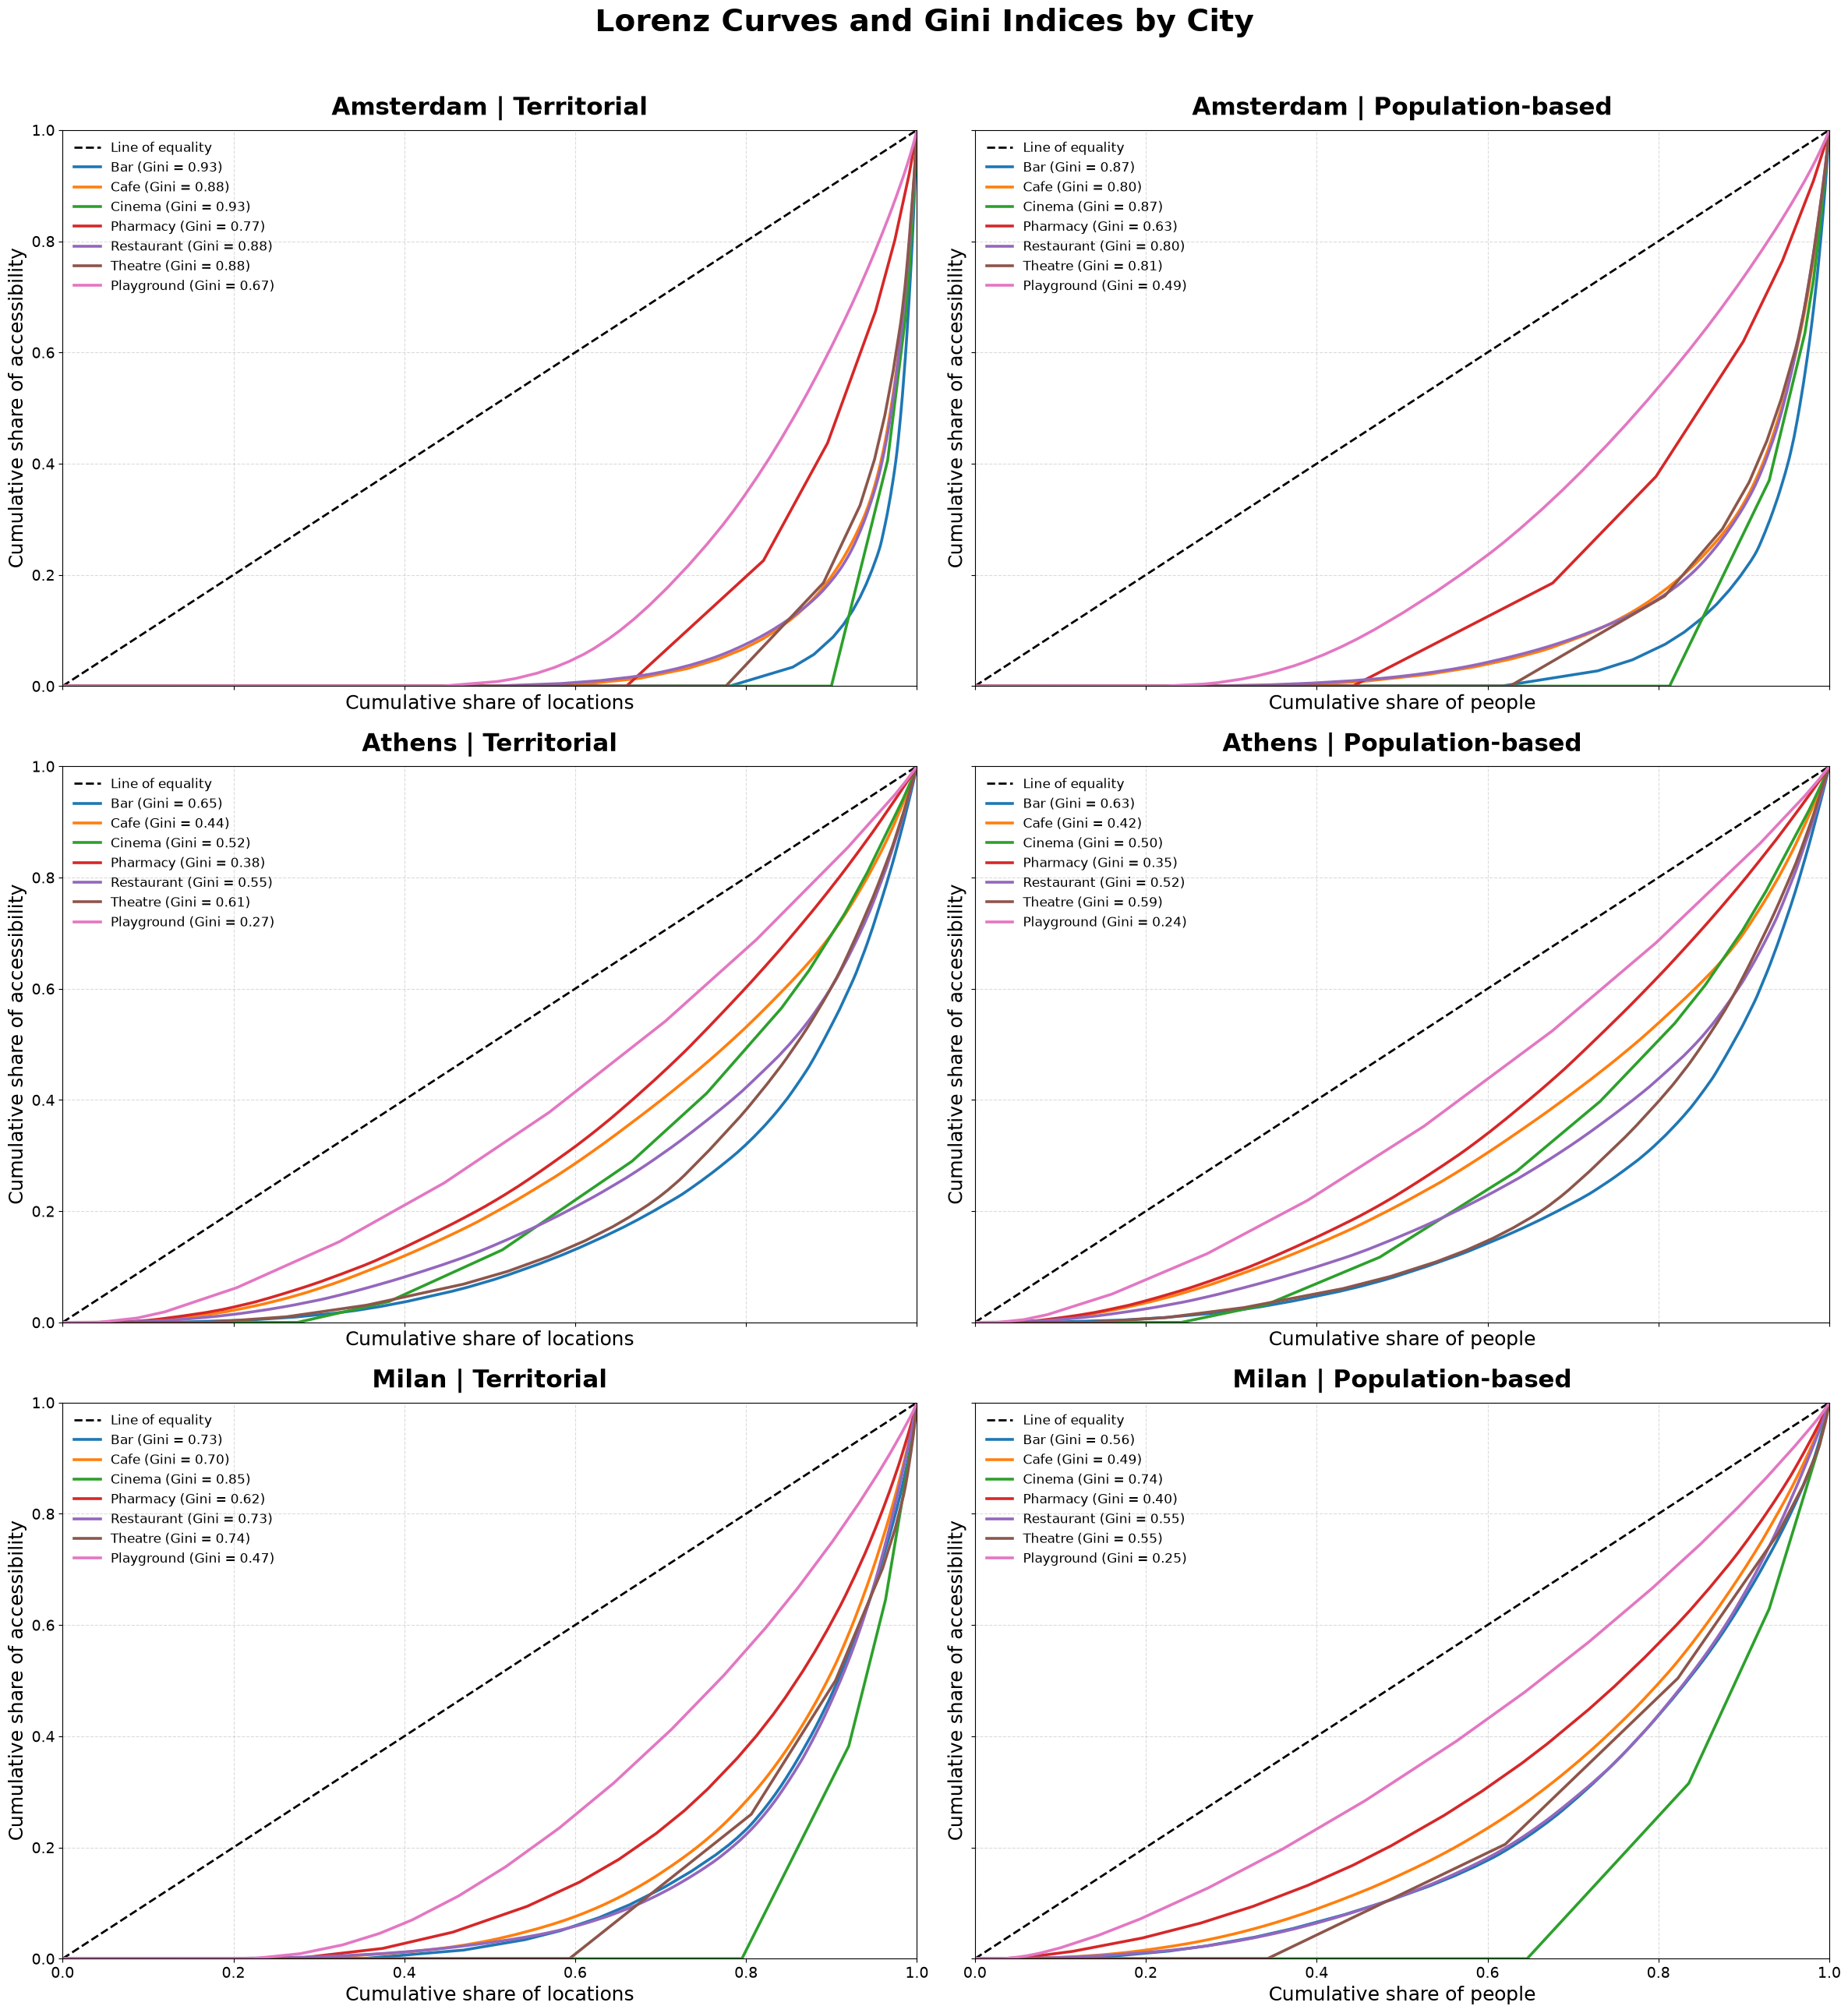

In [17]:
city_equity_data = {
    "Amsterdam": df_ams,
    "Athens": df_ath,
    "Milan": df_mil,
}

gini_territorial = {}
gini_population = {}

metric_labels = {
    metric: metric.replace("count_", "").replace("amenity_", "").replace("leisure_", "").replace("_", " ").title()
    for metric in poi_types
}

with plt.rc_context({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
}):
    fig_lorenz, axes_lorenz = plt.subplots(
        nrows=len(city_equity_data),
        ncols=2,
        figsize=(24, 26),
        sharex=True,
        sharey=True,
    )
    colors = plt.get_cmap("tab10").colors

    for row_idx, (city, city_df) in enumerate(city_equity_data.items()):
        for col_idx, (equity_type, weights, xlabel) in enumerate([
            ("Territorial", None, "Cumulative share of locations"),
            ("Population-based", "population", "Cumulative share of people"),
        ]):
            ax = axes_lorenz[row_idx, col_idx]
            A, P, gini, _ = acx.calculate_lorenz(
                properties=poi_types,
                df=city_df,
                weights=weights,
            )

            if weights is None:
                gini_territorial[city] = gini
            else:
                gini_population[city] = gini

            ax.plot([0, 1], [0, 1], "k--", linewidth=2.0, label="Line of equality")
            for metric_idx, metric in enumerate(poi_types):
                ax.plot(
                    P[metric],
                    A[metric],
                    linewidth=2.6,
                    color=colors[metric_idx % len(colors)],
                    label=f"{metric_labels[metric]} (Gini = {gini[metric]:.2f})",
                )

            ax.set_title(f"{city} | {equity_type}", pad=14, weight="bold")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Cumulative share of accessibility")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.grid(True, linestyle="--", alpha=0.45)
            ax.legend(frameon=False, loc="upper left")

    fig_lorenz.suptitle("Lorenz Curves and Gini Indices by City", fontsize=28, weight="bold", y=0.995)
    fig_lorenz.tight_layout(rect=(0, 0, 1, 0.985))
    fig_lorenz.savefig(results_path / "lorenz_curves_gini_all_cities.png", dpi=300, bbox_inches="tight")

gini_ams_terr = gini_territorial["Amsterdam"]
gini_ams_pop = gini_population["Amsterdam"]
gini_ath_terr = gini_territorial["Athens"]
gini_ath_pop = gini_population["Athens"]
gini_mil_terr = gini_territorial["Milan"]
gini_mil_pop = gini_population["Milan"]

fig_lorenz


## Egalitarian Summary


In [158]:
gini_ams_df = pd.DataFrame({
    "city": "Amsterdam",
    "metric": poi_types,
    "territorial_gini": [gini_ams_terr[metric] for metric in poi_types],
    "population_gini": [gini_ams_pop[metric] for metric in poi_types],
})

gini_ath_df = pd.DataFrame({
    "city": "Athens",
    "metric": poi_types,
    "territorial_gini": [gini_ath_terr[metric] for metric in poi_types],
    "population_gini": [gini_ath_pop[metric] for metric in poi_types],
})

gini_mil_df = pd.DataFrame({
    "city": "Milan",
    "metric": poi_types,
    "territorial_gini": [gini_mil_terr[metric] for metric in poi_types],
    "population_gini": [gini_mil_pop[metric] for metric in poi_types],
})

gini_summary = pd.concat([gini_ams_df, gini_ath_df, gini_mil_df], ignore_index=True)
gini_summary.to_csv(results_path / "gini_summary.csv", index=False)
# gini_summary = pd.read_csv(results_path / "gini_summary.csv")

gini_summary


,city,metric,territorial_gini,population_gini
0,Amsterdam,count_amenity_bar,0.933465,0.877671
1,Amsterdam,count_amenity_cafe,0.881647,0.800160
2,Amsterdam,count_amenity_cinema,0.930115,0.870543
3,Amsterdam,count_amenity_pharmacy,0.769740,0.622934
4,Amsterdam,count_amenity_restaurant,0.878783,0.796169
5,Amsterdam,count_amenity_theatre,0.885139,0.811932
6,Amsterdam,count_leisure_playground,0.677035,0.497209
7,Athens,count_amenity_bar,0.639220,0.625724
8,Athens,count_amenity_cafe,0.447873,0.422969
9,Athens,count_amenity_cinema,0.523875,0.500232


## Sufficientarian Equity Setup


In [18]:
poi_types

['count_amenity_bar',
 'count_amenity_cafe',
 'count_amenity_cinema',
 'count_amenity_pharmacy',
 'count_amenity_restaurant',
 'count_amenity_theatre',
 'count_leisure_playground']

Set the "enough" bar per category: a hex passes a category if its reachable count >= this number. The score is the share of categories passed.

In [19]:
thresholds_ge = {
    "count_amenity_bar": 1,
    "count_amenity_cafe": 1,
    "count_amenity_cinema": 1,
    "count_amenity_pharmacy": 1,
    "count_amenity_restaurant": 1,
    "count_amenity_theatre": 1,
    "count_leisure_playground": 1,
}

df_ams_suff = acx.compute_sufficientarian_score(df_ams, thresholds_ge=thresholds_ge)
acx.save_gdf(df_ams_suff, results_path / "sufficientarian_amsterdam.geojson")
# df_ams_suff = acx.read_gdf(results_path / "sufficientarian_amsterdam.geojson")

df_ath_suff = acx.compute_sufficientarian_score(df_ath, thresholds_ge=thresholds_ge)
acx.save_gdf(df_ath_suff, results_path / "sufficientarian_athens.geojson")
# df_ath_suff = acx.read_gdf(results_path / "sufficientarian_athens.geojson")

df_mil_suff = acx.compute_sufficientarian_score(df_mil, thresholds_ge=thresholds_ge)
acx.save_gdf(df_mil_suff, results_path / "sufficientarian_milan.geojson")
# df_mil_suff = acx.read_gdf(results_path / "sufficientarian_milan.geojson")


## Sufficientarian Equity | Amsterdam


Amsterdam territorial sufficientarian score: 0.3355441490282023
Amsterdam population-based sufficientarian score: 0.5222950406335097


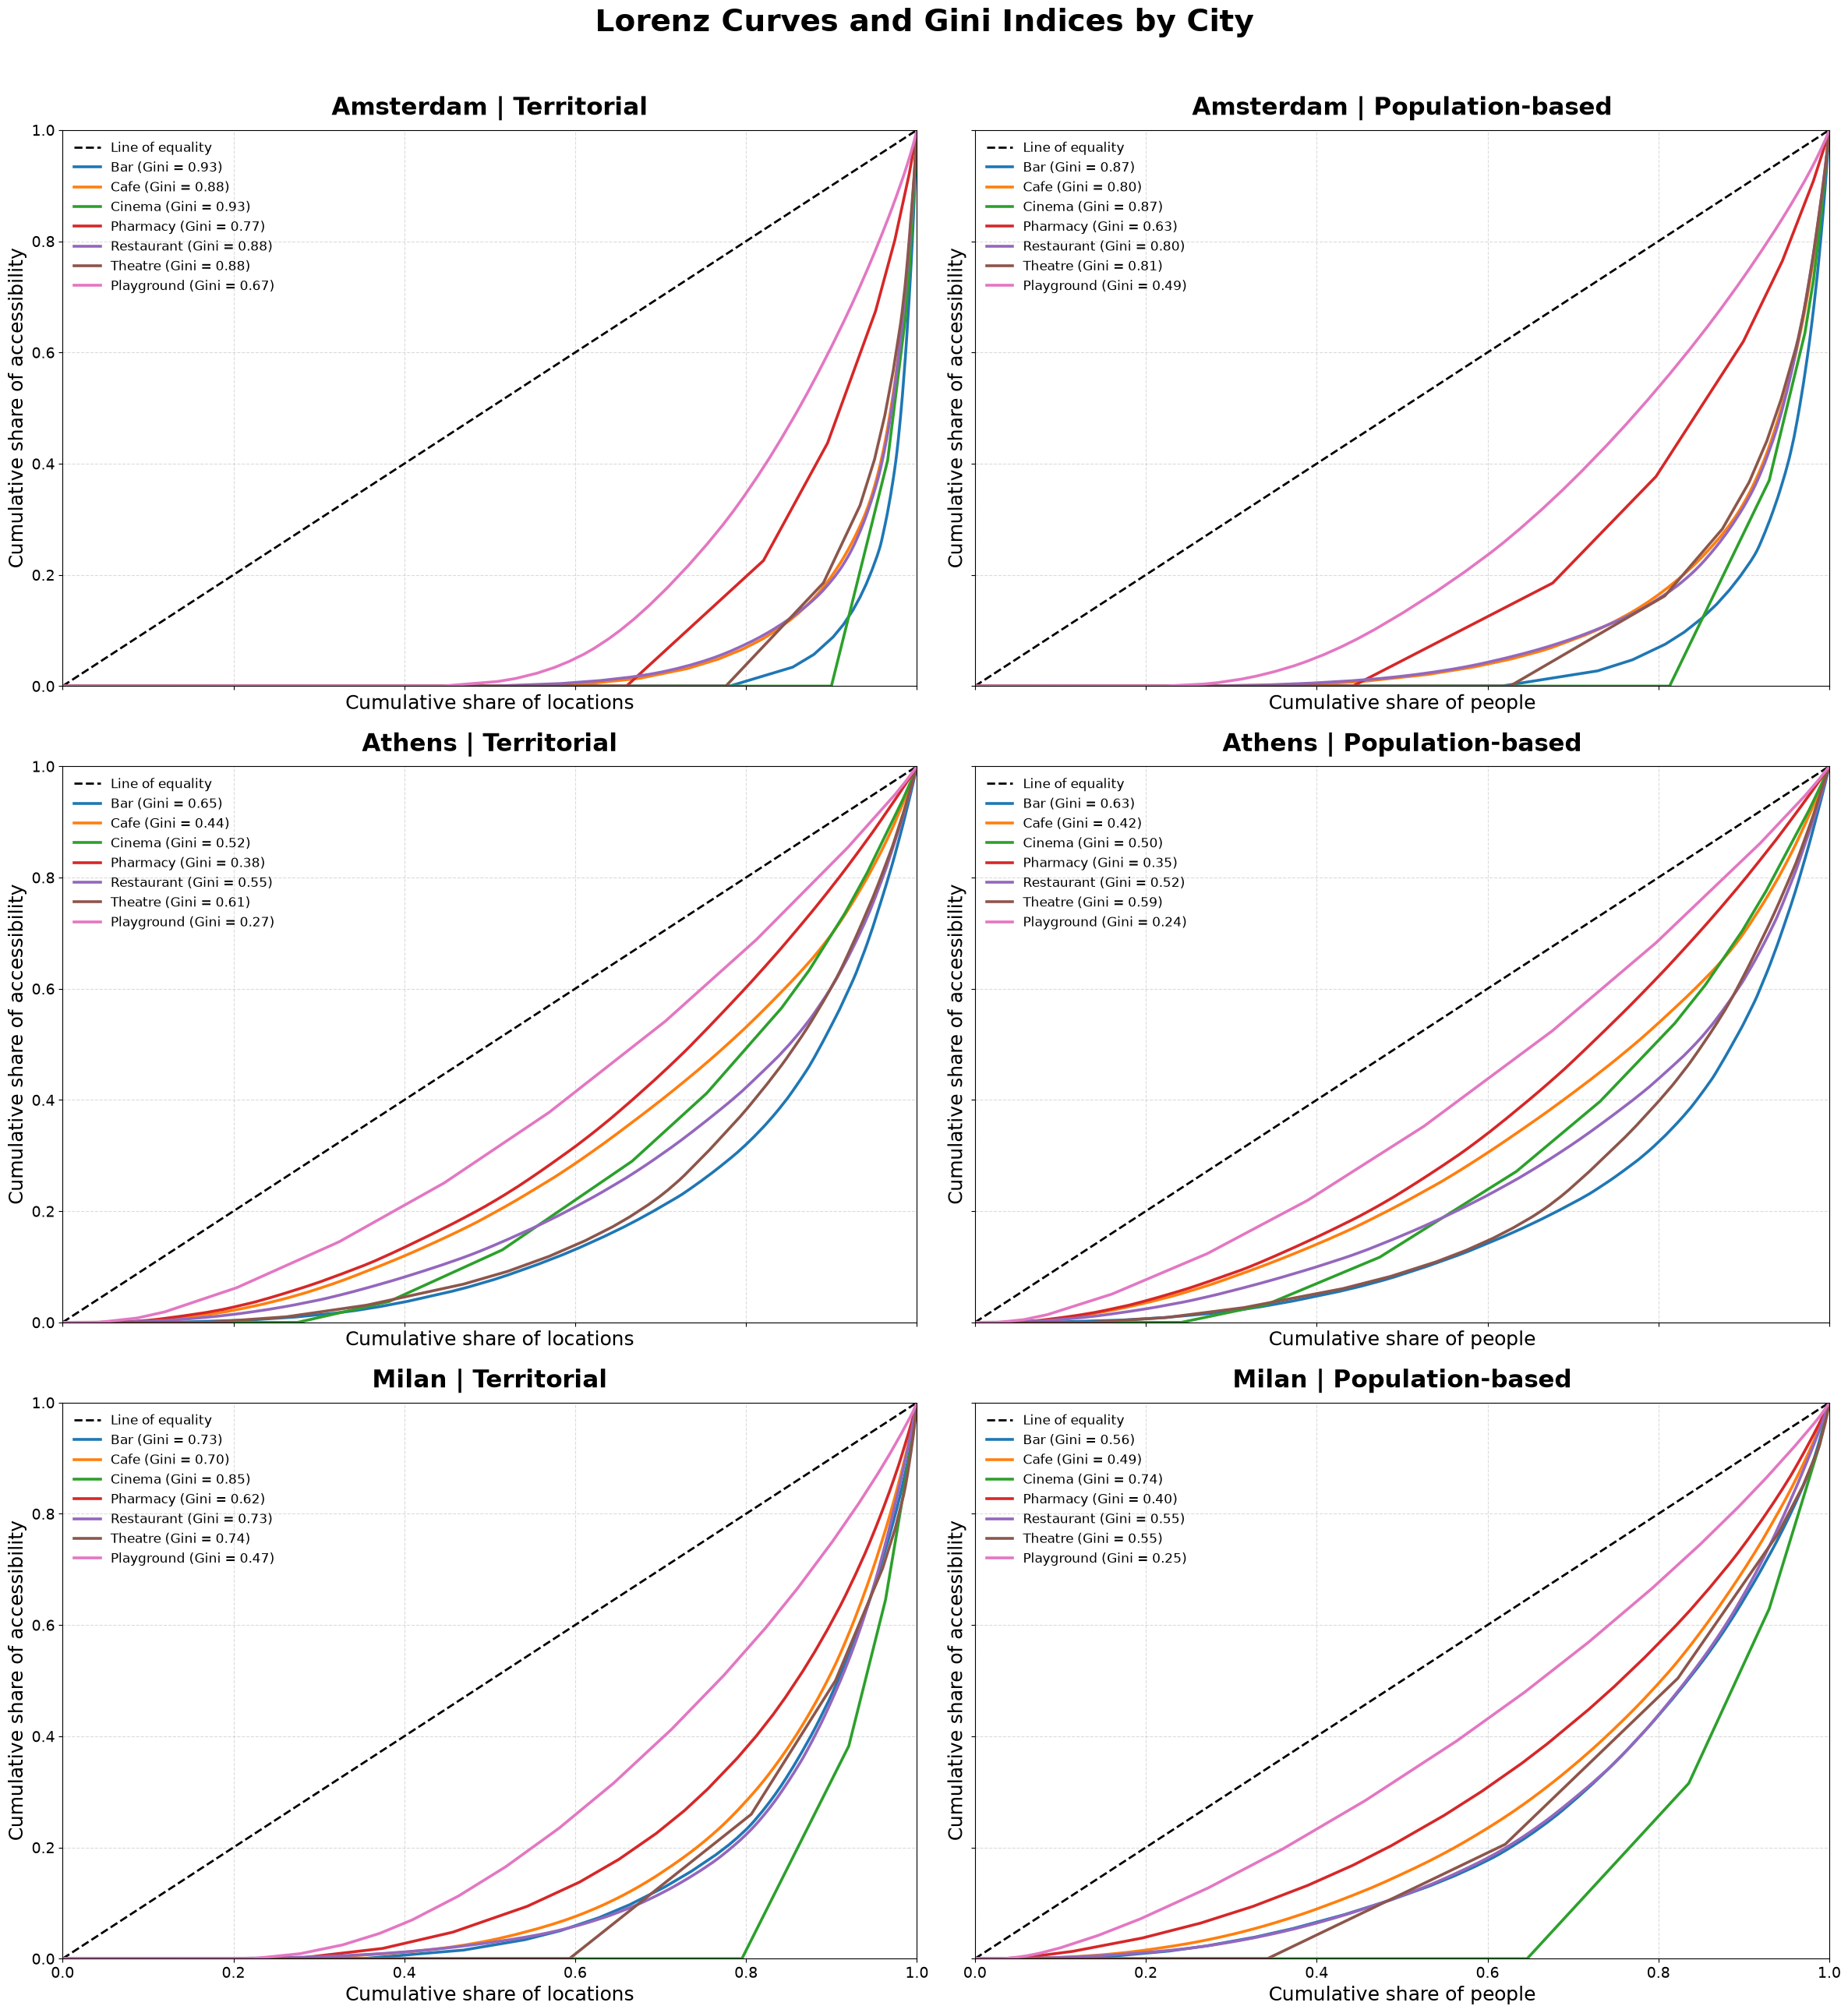

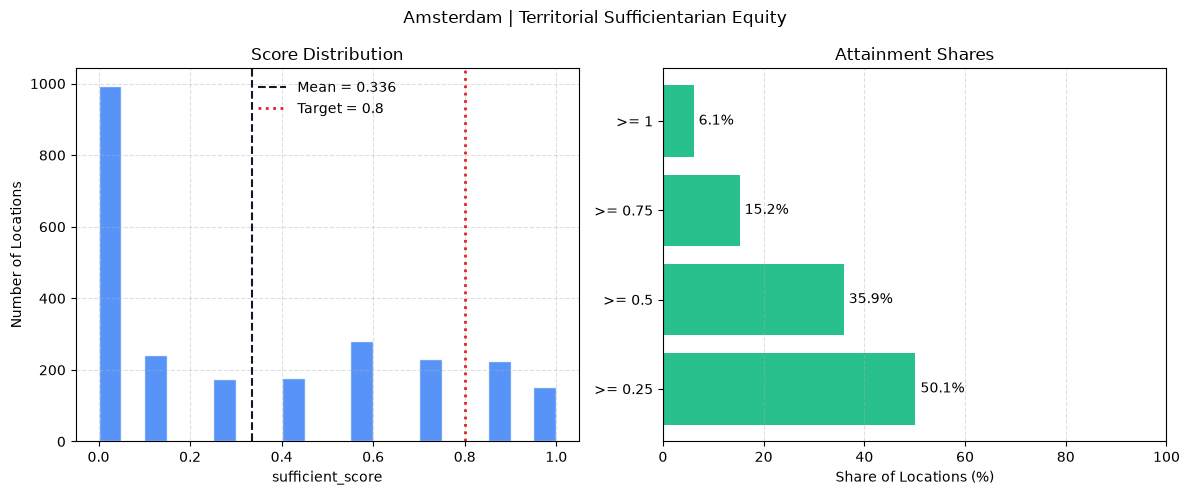

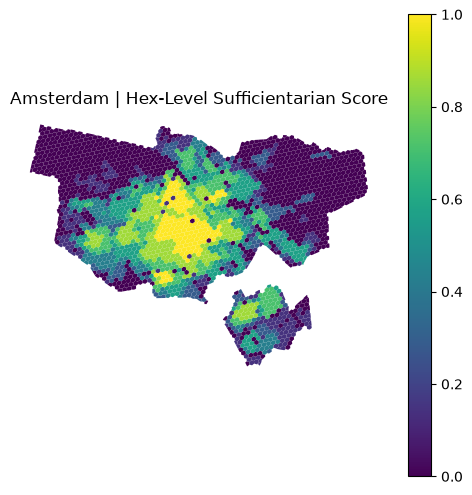

In [20]:
territorial_suff_ams = df_ams_suff["sufficient_score"].mean()
population_suff_ams = (
    (df_ams_suff["sufficient_score"] * df_ams_suff["population"]).sum()
    / df_ams_suff["population"].sum()
)

print("Amsterdam territorial sufficientarian score:", territorial_suff_ams)
print("Amsterdam population-based sufficientarian score:", population_suff_ams)

acx.plot_sufficientarian_score(
    df=df_ams_suff,
    score_col="sufficient_score",
    title="Amsterdam | Territorial Sufficientarian Equity",
)

df_ams_suff.plot(column="sufficient_score", figsize=(6, 6), legend=True)
plt.title("Amsterdam | Hex-Level Sufficientarian Score")
plt.axis("off")
plt.show()


## Sufficientarian Equity | Athens


Athens territorial sufficientarian score: 0.896440129449838
Athens population-based sufficientarian score: 0.9200791317206441


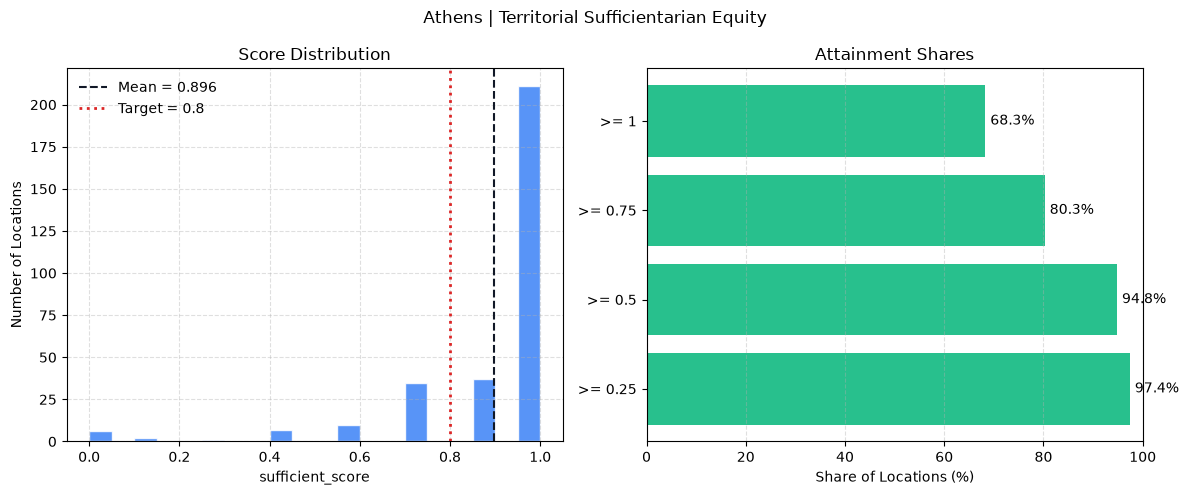

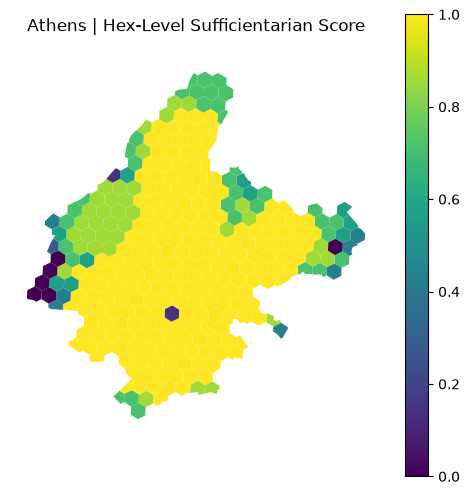

In [21]:
territorial_suff_ath = df_ath_suff["sufficient_score"].mean()
population_suff_ath = (
    (df_ath_suff["sufficient_score"] * df_ath_suff["population"]).sum()
    / df_ath_suff["population"].sum()
)

print("Athens territorial sufficientarian score:", territorial_suff_ath)
print("Athens population-based sufficientarian score:", population_suff_ath)

acx.plot_sufficientarian_score(
    df=df_ath_suff,
    score_col="sufficient_score",
    title="Athens | Territorial Sufficientarian Equity",
)

df_ath_suff.plot(column="sufficient_score", figsize=(6, 6), legend=True)
plt.title("Athens | Hex-Level Sufficientarian Score")
plt.axis("off")
plt.show()


## Sufficientarian Equity | Milan


Milan territorial sufficientarian score: 0.6195393820178673
Milan population-based sufficientarian score: 0.8242120645857898


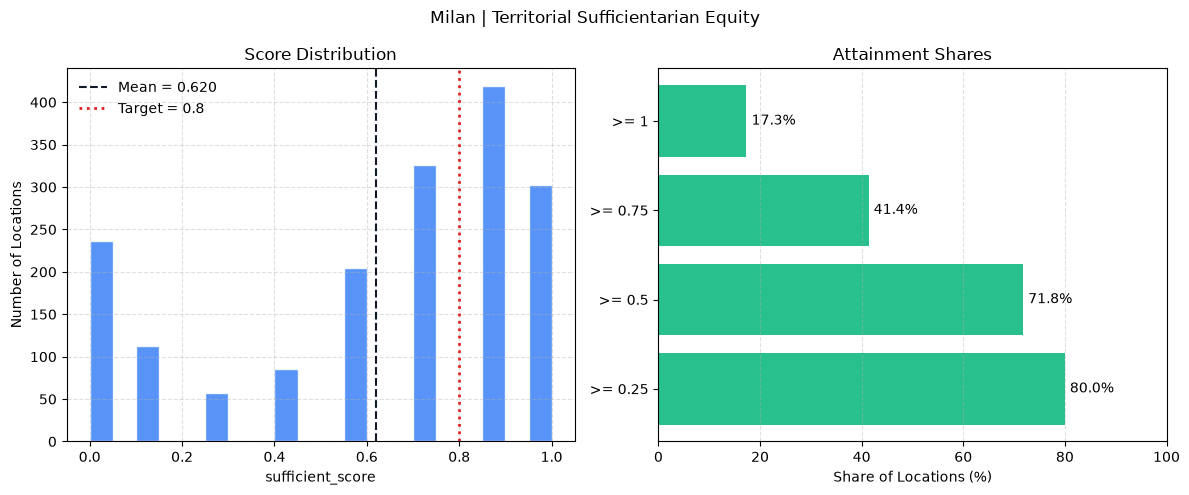

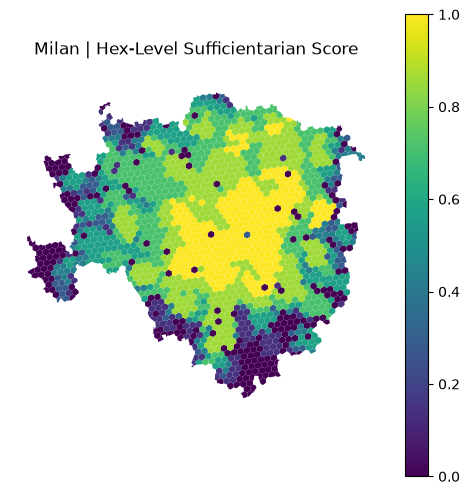

In [22]:
territorial_suff_mil = df_mil_suff["sufficient_score"].mean()
population_suff_mil = (
    (df_mil_suff["sufficient_score"] * df_mil_suff["population"]).sum()
    / df_mil_suff["population"].sum()
)

print("Milan territorial sufficientarian score:", territorial_suff_mil)
print("Milan population-based sufficientarian score:", population_suff_mil)

acx.plot_sufficientarian_score(
    df=df_mil_suff,
    score_col="sufficient_score",
    title="Milan | Territorial Sufficientarian Equity",
)

df_mil_suff.plot(column="sufficient_score", figsize=(6, 6), legend=True)
plt.title("Milan | Hex-Level Sufficientarian Score")
plt.axis("off")
plt.show()


## Sufficientarian Summary


In [23]:
sufficientarian_summary = pd.DataFrame(
    {
        "city": ["Amsterdam", "Athens", "Milan"],
        "territorial_sufficientarian": [
            territorial_suff_ams,
            territorial_suff_ath,
            territorial_suff_mil,
        ],
        "population_based_sufficientarian": [
            population_suff_ams,
            population_suff_ath,
            population_suff_mil,
        ],
    }
)

sufficientarian_summary.to_csv(results_path / "sufficientarian_summary.csv", index=False)
# sufficientarian_summary = pd.read_csv(results_path / "sufficientarian_summary.csv")

sufficientarian_summary


,city,territorial_sufficientarian,population_based_sufficientarian
0,Amsterdam,0.335544,0.522295
1,Athens,0.896440,0.920079
2,Milan,0.619539,0.824212
